<a href="https://colab.research.google.com/github/Madhan522/Brain_tumor_Detection/blob/main/Unet_Model_2nd_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTS

import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [2]:
# PARAMETERS

IMG_SIZE = (256,256)
BATCH_SIZE = 2
EPOCHS = 10


In [3]:
#  DATASET PATH

train_images_dir = './brisc2025/segmentation_task/train/images'
train_masks_dir  = './brisc2025/segmentation_task/train/masks'

test_images_dir  = './brisc2025/segmentation_task/test/images'
test_masks_dir   = './brisc2025/segmentation_task/test/masks'



In [8]:
# LOAD DATA

def load_image_mask_pairs(images_dir, masks_dir, size=IMG_SIZE):

    image_files = sorted(os.listdir(images_dir))
    mask_files  = sorted(os.listdir(masks_dir))

    images, masks = [], []

    for img_file, mask_file in zip(image_files, mask_files):

        img = Image.open(os.path.join(images_dir, img_file)).convert('L').resize(size)
        mask = Image.open(os.path.join(masks_dir, mask_file)).resize(size, resample=Image.NEAREST)

        image = np.array(img) / 255.0
        mask  = np.array(mask)


        mask = (mask > 0).astype(np.uint8)

        images.append(image)
        masks.append(mask)

    images = np.array(images)[..., np.newaxis]   # shape (N,256,256,1)
    masks  = np.array(masks)[..., np.newaxis]    # shape (N,256,256,1)

    return images, masks

# Load dataset
X, Y = load_image_mask_pairs(train_images_dir, train_masks_dir)

print("Train Images:", X.shape)
print("Train Masks:", Y.shape)

# Split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)

Train Images: (3933, 256, 256, 1)
Train Masks: (3933, 256, 256, 1)


In [9]:
# U-NET MODEL

def unet_model():

    inputs = layers.Input((256,256,1))

    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128,3,activation='relu',padding='same')(p2)
    c3 = layers.Conv2D(128,3,activation='relu',padding='same')(c3)
    p3 = layers.MaxPooling2D()(c3)

    c4 = layers.Conv2D(256,3,activation='relu',padding='same')(p3)
    c4 = layers.Conv2D(256,3,activation='relu',padding='same')(c4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128,3,activation='relu',padding='same')(u5)

    u6 = layers.UpSampling2D()(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64,3,activation='relu',padding='same')(u6)

    u7 = layers.UpSampling2D()(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32,3,activation='relu',padding='same')(u7)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c7)

    return models.Model(inputs, outputs)

model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
#  TRAIN

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop]
)



Epoch 1/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 59s 33ms/step - accuracy: 0.9813 - loss: 0.0733 - val_accuracy: 0.9821 - val_loss: 0.0623
Epoch 2/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9842 - loss: 0.0562 - val_accuracy: 0.9855 - val_loss: 0.0545
Epoch 3/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9870 - loss: 0.0460 - val_accuracy: 0.9884 - val_loss: 0.0406
Epoch 4/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9887 - loss: 0.0393 - val_accuracy: 0.9895 - val_loss: 0.0364
Epoch 5/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9897 - loss: 0.0346 - val_accuracy: 0.9894 - val_loss: 0.0357
Epoch 6/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9904 - loss: 0.0314 - val_accuracy: 0.9892 - val_loss: 0.0358
Epoch 7/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9906 - loss: 0.0299 - val_accuracy: 0.9908 - val_loss: 0.0304
Epoch 8/10
1573/1573 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9913 -

In [11]:
# K-FOLD CROSS VALIDATION

print("\n--- K-FOLD CROSS VALIDATION ---")

kf = KFold(n_splits=3, shuffle=True, random_state=42)
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

    print(f"\nFold {fold+1}")

    X_train_k, X_val_k = X[train_idx], X[val_idx]
    Y_train_k, Y_val_k = Y[train_idx], Y[val_idx]

    model_k = unet_model()
    model_k.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model_k.fit(X_train_k, Y_train_k, epochs=3, batch_size=2, verbose=0)

    _, acc = model_k.evaluate(X_val_k, Y_val_k, verbose=0)

    print("Accuracy:", acc)
    fold_accuracies.append(acc)

print("\nK-Fold Accuracies:", fold_accuracies)
print("Average K-Fold Accuracy:", np.mean(fold_accuracies))


--- K-FOLD CROSS VALIDATION ---

Fold 1
Accuracy: 0.9856688976287842

Fold 2
Accuracy: 0.9814580678939819

Fold 3
Accuracy: 0.9893428087234497

K-Fold Accuracies: [0.9856688976287842, 0.9814580678939819, 0.9893428087234497]
Average K-Fold Accuracy: 0.9854899247487386


In [12]:
#TEST

X_test, Y_test = load_image_mask_pairs(test_images_dir, test_masks_dir)

pred = model.predict(X_test)
pred_masks = (pred > 0.5).astype(np.uint8)

27/27 ━━━━━━━━━━━━━━━━━━━━ 16s 587ms/step



Test Accuracy: 0.9905216838038244
IoU: 0.6162430093854282


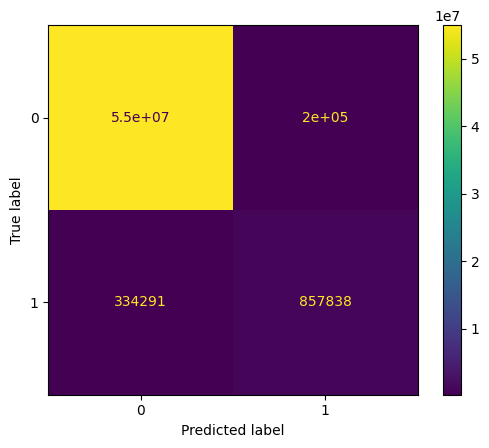

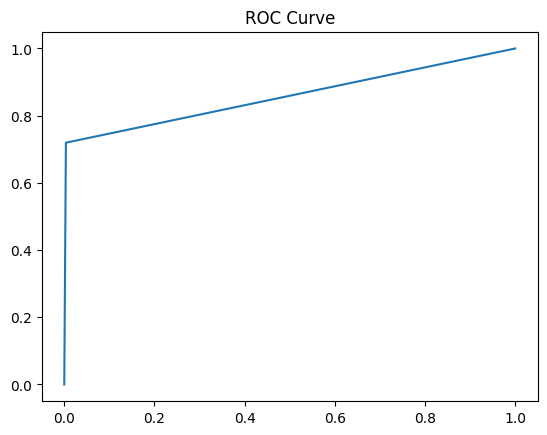

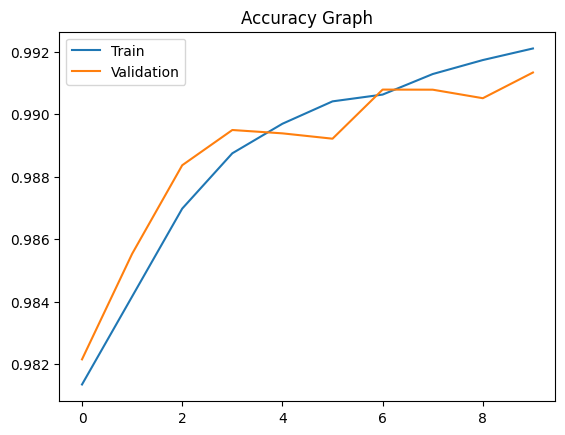

In [13]:
# METRICS

y_true = Y_test.flatten()
y_pred = pred_masks.flatten()

print("\nTest Accuracy:", accuracy_score(y_true, y_pred))

def iou(y_true, y_pred):
    inter = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    return np.sum(inter) / (np.sum(union) + 1e-7)

print("IoU:", iou(Y_test, pred_masks))

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred)).plot()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred)
plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title("Accuracy Graph")
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


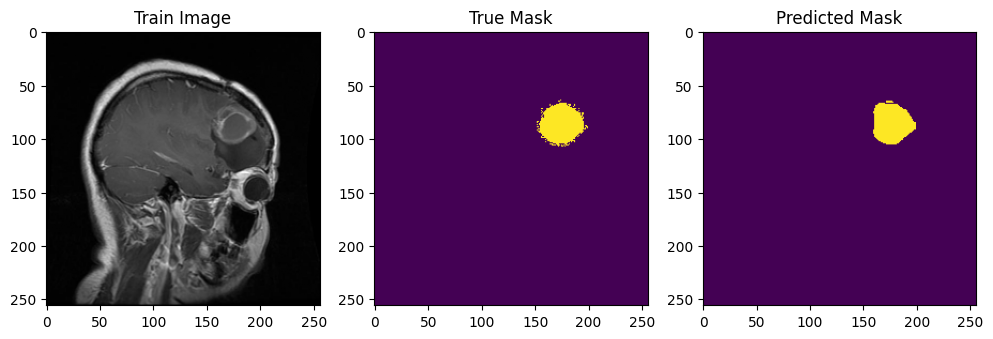

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


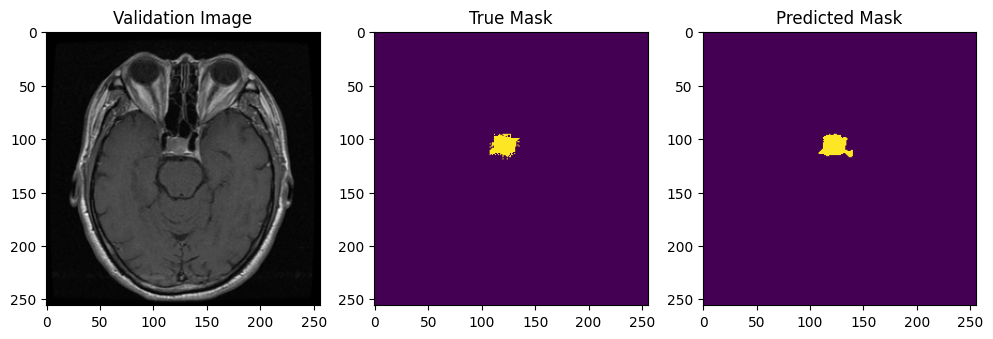

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


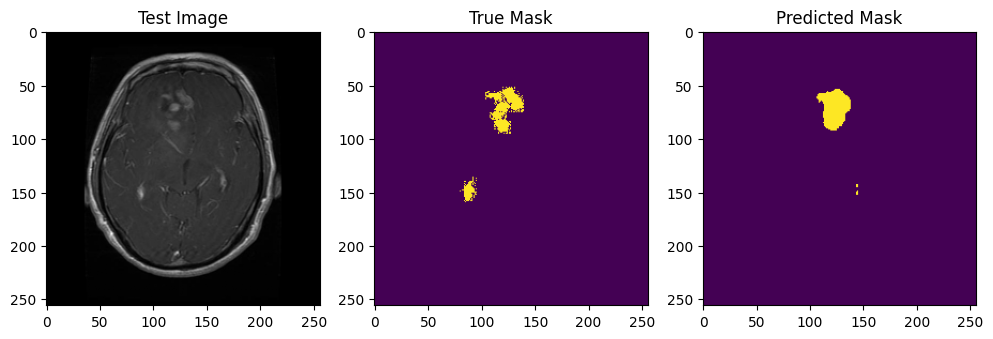

In [19]:
# VISUALIZATION

def show_prediction(X_data, Y_data, title, index=0):

    pred = model.predict(X_data[index:index+1])
    pred_mask = (pred[0] > 0.5).astype(np.uint8).squeeze()

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title(title+" Image")
    plt.imshow(X_data[index].squeeze(), cmap='gray')

    plt.subplot(1,3,2)
    plt.title("True Mask")
    plt.imshow(Y_data[index].squeeze())

    plt.subplot(1,3,3)
    plt.title("Predicted Mask")
    plt.imshow(pred_mask)

    plt.show()

# Show samples
show_prediction(X_train, Y_train, "Train", 33)
show_prediction(X_val, Y_val, "Validation", 33)
show_prediction(X_test, Y_test, "Test", 33)